# 📄 StatParse — Pipeline d'Analyse Documentaire
## Évaluation sur OmniDocBench · ENSAE 2025 · Projet RAG

---
Ce notebook présente les résultats de notre pipeline **StatParse** évalué sur le benchmark [OmniDocBench](https://github.com/opendatalab/OmniDocBench), comparé au baseline **Docling**.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titleweight': 'bold',
})

# ── Couleurs ──────────────────────────────────────────────────────
C_STATPARSE = '#2563EB'   # bleu vif
C_DOCLING   = '#16A34A'   # vert
C_LIGHT_SP  = '#DBEAFE'
C_LIGHT_DL  = '#DCFCE7'

print('✅ Imports OK')

✅ Imports OK


In [2]:
# ── Chargement des résultats ──────────────────────────────────────
RESULT_DIR = '../result'

with open(f'{RESULT_DIR}/statparse_quick_match_metric_result.json') as f:
    sp = json.load(f)

with open(f'{RESULT_DIR}/docling_quick_match_metric_result.json') as f:
    dl = json.load(f)

print('✅ Résultats chargés')
print(f'   StatParse — catégories: {list(sp.keys())}')
print(f'   Docling   — catégories: {list(dl.keys())}')

✅ Résultats chargés
   StatParse — catégories: ['text_block', 'display_formula', 'table', 'reading_order']
   Docling   — catégories: ['text_block', 'display_formula', 'table', 'reading_order']


In [3]:
# ── Tableau de synthèse ───────────────────────────────────────────
def extract_scores(result):
    """Extrait les métriques principales d'un résultat JSON."""
    scores = {}
    scores['text_Edit_dist']      = result['text_block']['all']['Edit_dist']['ALL_page_avg']
    scores['formula_Edit_dist']   = result['display_formula']['all']['Edit_dist']['ALL_page_avg']
    scores['table_TEDS']          = result['table']['page']['TEDS']['ALL'] * 100
    scores['table_TEDS_struct']   = result['table']['page']['TEDS_structure_only']['ALL'] * 100
    scores['table_Edit_dist']     = result['table']['all']['Edit_dist']['ALL_page_avg']
    scores['reading_order']       = result['reading_order']['all']['Edit_dist']['ALL_page_avg']
    # Score global (convention OmniDocBench)
    scores['overall'] = (
        (1 - scores['text_Edit_dist']) * 100 +
        (1 - scores['reading_order']) * 100 +
        scores['table_TEDS']
    ) / 3
    return scores

sp_scores = extract_scores(sp)
dl_scores = extract_scores(dl)

df = pd.DataFrame({
    'StatParse': sp_scores,
    'Docling':   dl_scores
}).T.round(3)

# Affichage lisible
df_display = df.copy()
df_display.columns = [
    'Text Edit↓', 'Formula Edit↓', 
    'Table TEDS↑', 'Table TEDS-S↑',
    'Table Edit↓', 'Reading Order↓', 'Overall↑'
]

print('\n📊 SCORES GLOBAUX\n')
print(df_display.to_string())
df_display


📊 SCORES GLOBAUX

           Text Edit↓  Formula Edit↓  Table TEDS↑  Table TEDS-S↑  Table Edit↓  Reading Order↓  Overall↑
StatParse       0.384          0.960       15.574         17.433        0.834           0.353    47.316
Docling         0.176          0.345       66.734         73.664        0.643           0.183    76.923


,Text Edit↓,Formula Edit↓,Table TEDS↑,Table TEDS-S↑,Table Edit↓,Reading Order↓,Overall↑
StatParse,0.384,0.960,15.574,17.433,0.834,0.353,47.316
Docling,0.176,0.345,66.734,73.664,0.643,0.183,76.923


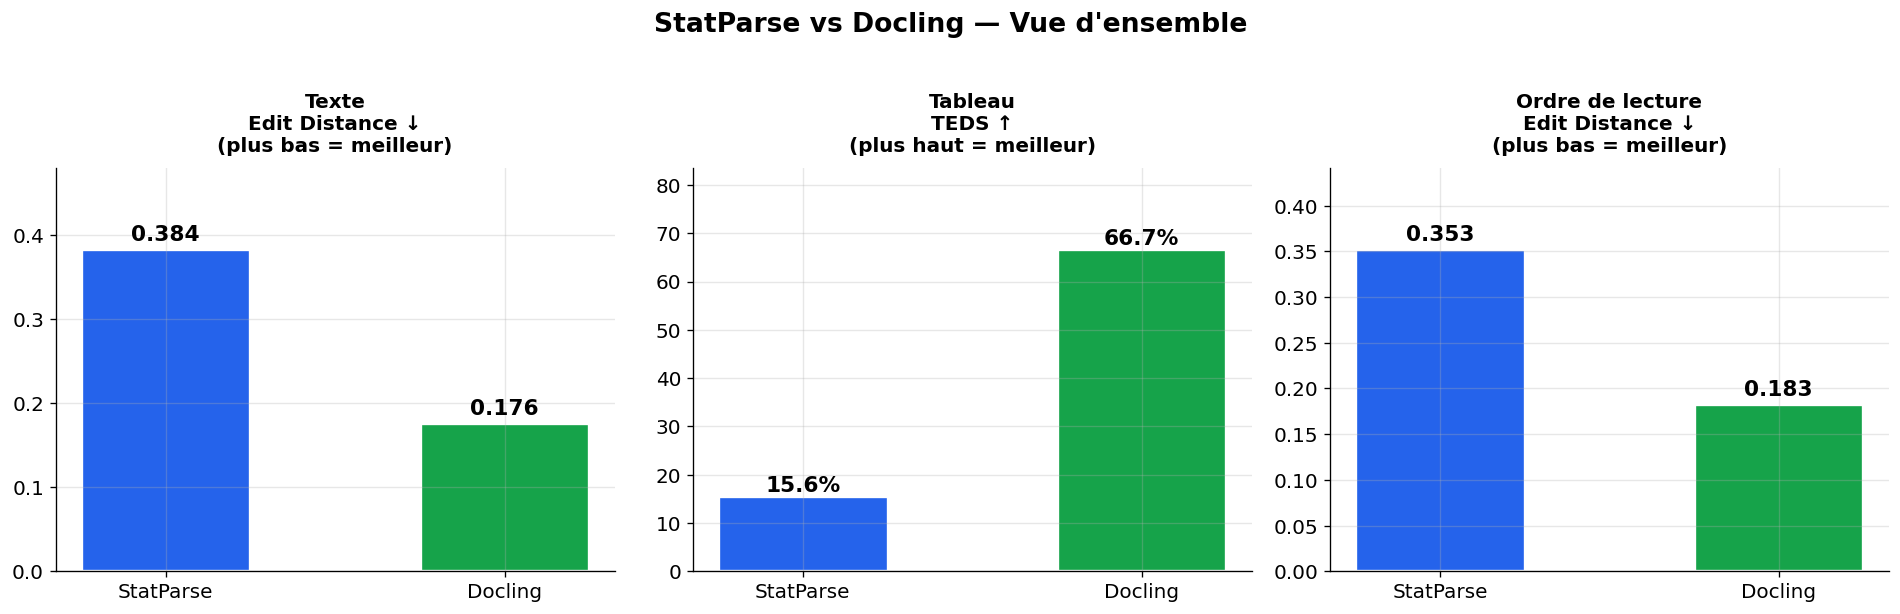

Figure 1 sauvegardée.


In [4]:
# ═══════════════════════════════════════════════════════════════════
# FIGURE 1 — Vue d'ensemble : StatParse vs Docling
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('StatParse vs Docling — Vue d\'ensemble', 
             fontsize=16, fontweight='bold', y=1.02)

metrics_info = [
    ('text_Edit_dist',  'Texte\nEdit Distance ↓\n(plus bas = meilleur)', False),
    ('table_TEDS',      'Tableau\nTEDS ↑\n(plus haut = meilleur)',        True),
    ('reading_order',   'Ordre de lecture\nEdit Distance ↓\n(plus bas = meilleur)', False),
]

for ax, (key, title, higher_better) in zip(axes, metrics_info):
    sp_val = sp_scores[key]
    dl_val = dl_scores[key]
    
    # Pour TEDS, on affiche directement; pour Edit Distance, on affiche (1-val)*100
    if not higher_better:
        sp_disp = sp_val
        dl_disp = dl_val
    else:
        sp_disp = sp_val
        dl_disp = dl_val
    
    bars = ax.bar(['StatParse', 'Docling'], 
                   [sp_disp, dl_disp],
                   color=[C_STATPARSE, C_DOCLING],
                   width=0.5, edgecolor='white', linewidth=2)
    
    # Valeurs sur les barres
    for bar, val in zip(bars, [sp_disp, dl_disp]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}' if not higher_better else f'{val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=13)
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_ylim(0, max(sp_disp, dl_disp) * 1.25)
    ax.tick_params(axis='x', labelsize=12)
    ax.set_ylabel('')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 sauvegardée.')

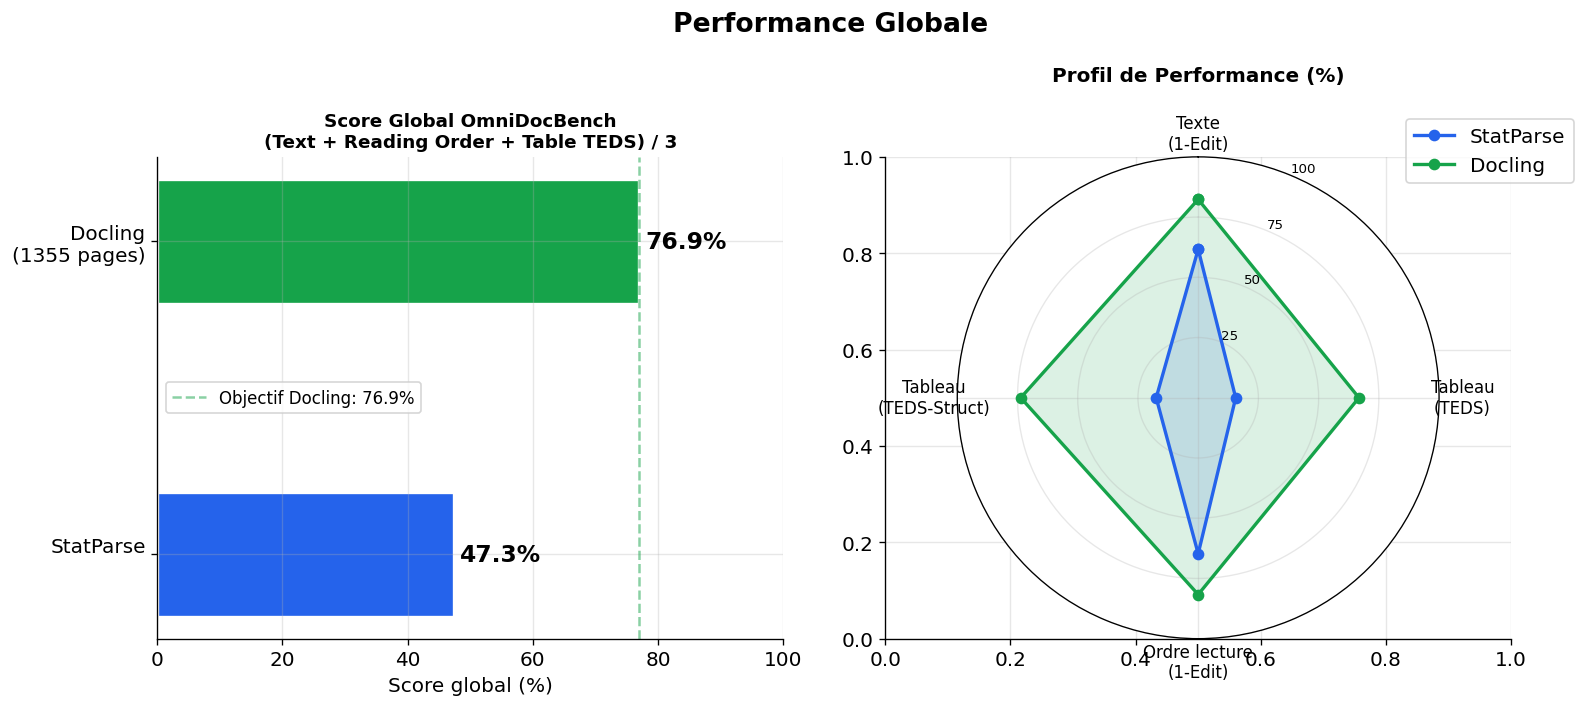

Figure 2 sauvegardée.


In [5]:
# ═══════════════════════════════════════════════════════════════════
# FIGURE 2 — Score global et radar
# ═══════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Performance Globale', fontsize=16, fontweight='bold')

# ── Jauge score global ────────────────────────────────────────────
models    = ['StatParse\n', 'Docling\n(1355 pages)']
overalls  = [sp_scores['overall'], dl_scores['overall']]
colors    = [C_STATPARSE, C_DOCLING]

bars = ax1.barh(models, overalls, color=colors, height=0.4,
                edgecolor='white', linewidth=2)
ax1.set_xlim(0, 100)
ax1.set_xlabel('Score global (%)', fontsize=12)
ax1.set_title('Score Global OmniDocBench\n(Text + Reading Order + Table TEDS) / 3', fontsize=11)

for bar, val in zip(bars, overalls):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=14)

# Ligne objectif Docling
ax1.axvline(dl_scores['overall'], color=C_DOCLING, linestyle='--', 
            alpha=0.5, linewidth=1.5, label=f'Objectif Docling: {dl_scores["overall"]:.1f}%')
ax1.legend(fontsize=10)

# ── Radar chart ───────────────────────────────────────────────────
categories = ['Texte\n(1-Edit)', 'Tableau\n(TEDS)', 'Ordre lecture\n(1-Edit)',
              'Tableau\n(TEDS-Struct)']
N = len(categories)

sp_vals = [
    (1 - sp_scores['text_Edit_dist']) * 100,
    sp_scores['table_TEDS'],
    (1 - sp_scores['reading_order']) * 100,
    sp_scores['table_TEDS_struct'],
]
dl_vals = [
    (1 - dl_scores['text_Edit_dist']) * 100,
    dl_scores['table_TEDS'],
    (1 - dl_scores['reading_order']) * 100,
    dl_scores['table_TEDS_struct'],
]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
sp_vals += sp_vals[:1]
dl_vals += dl_vals[:1]

ax2 = plt.subplot(122, polar=True)
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, size=10)
ax2.set_ylim(0, 100)
ax2.set_yticks([25, 50, 75, 100])
ax2.set_yticklabels(['25', '50', '75', '100'], size=8)

ax2.plot(angles, sp_vals, 'o-', linewidth=2, color=C_STATPARSE, label='StatParse')
ax2.fill(angles, sp_vals, alpha=0.15, color=C_STATPARSE)
ax2.plot(angles, dl_vals, 'o-', linewidth=2, color=C_DOCLING, label='Docling')
ax2.fill(angles, dl_vals, alpha=0.15, color=C_DOCLING)
ax2.set_title('Profil de Performance (%)', fontsize=12, pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('fig2_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 sauvegardée.')

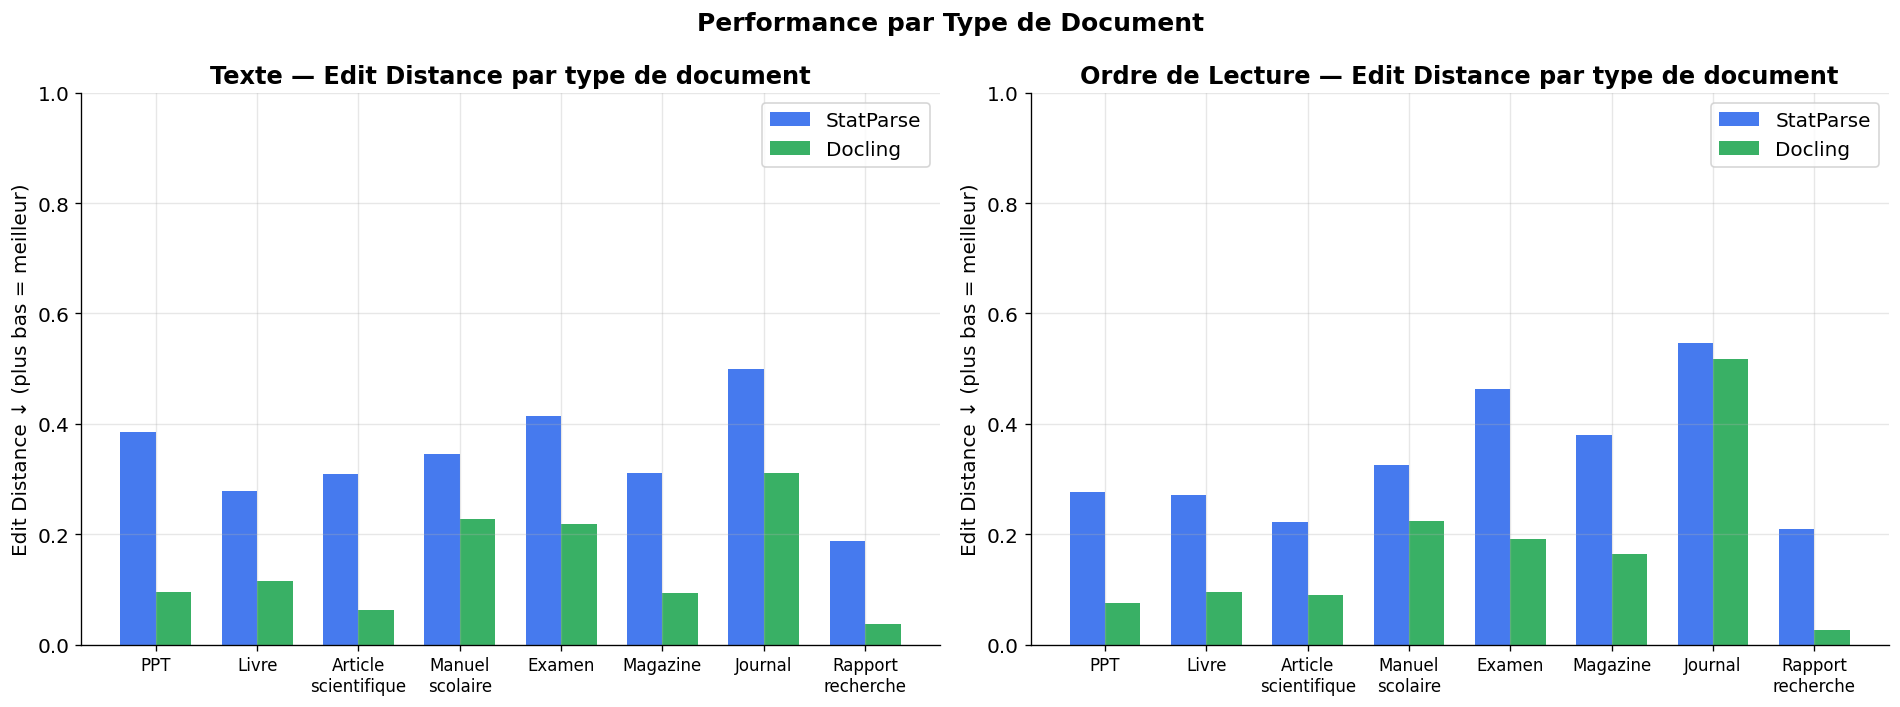

Figure 3 sauvegardée.


In [6]:
# ═══════════════════════════════════════════════════════════════════
# FIGURE 3 — Performance par type de document
# ═══════════════════════════════════════════════════════════════════

doc_types = {
    'PPT': 'data_source: PPT2PDF',
    'Livre': 'data_source: book',
    'Article\nscientifique': 'data_source: academic_literature',
    'Manuel\nscolaire': 'data_source: colorful_textbook',
    'Examen': 'data_source: exam_paper',
    'Magazine': 'data_source: magazine',
    'Journal': 'data_source: newspaper',
    'Rapport\nrecherche': 'data_source: research_report',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance par Type de Document', fontsize=15, fontweight='bold')

x = np.arange(len(doc_types))
w = 0.35
labels = list(doc_types.keys())
keys   = list(doc_types.values())

# ── Texte (Edit Distance) ─────────────────────────────────────────
ax = axes[0]
sp_text = [sp['text_block']['page']['Edit_dist'].get(k, np.nan) for k in keys]
dl_text = [dl['text_block']['page']['Edit_dist'].get(k, np.nan) for k in keys]

b1 = ax.bar(x - w/2, sp_text, w, label='StatParse', color=C_STATPARSE, alpha=0.85)
b2 = ax.bar(x + w/2, dl_text, w, label='Docling',   color=C_DOCLING,   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Edit Distance ↓ (plus bas = meilleur)')
ax.set_title('Texte — Edit Distance par type de document')
ax.legend()
ax.set_ylim(0, 1)

# ── Reading Order ─────────────────────────────────────────────────
ax = axes[1]
sp_ro = [sp['reading_order']['page']['Edit_dist'].get(k, np.nan) for k in keys]
dl_ro = [dl['reading_order']['page']['Edit_dist'].get(k, np.nan) for k in keys]

b1 = ax.bar(x - w/2, sp_ro, w, label='StatParse', color=C_STATPARSE, alpha=0.85)
b2 = ax.bar(x + w/2, dl_ro, w, label='Docling',   color=C_DOCLING,   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Edit Distance ↓ (plus bas = meilleur)')
ax.set_title('Ordre de Lecture — Edit Distance par type de document')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('fig3_by_doctype.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 sauvegardée.')

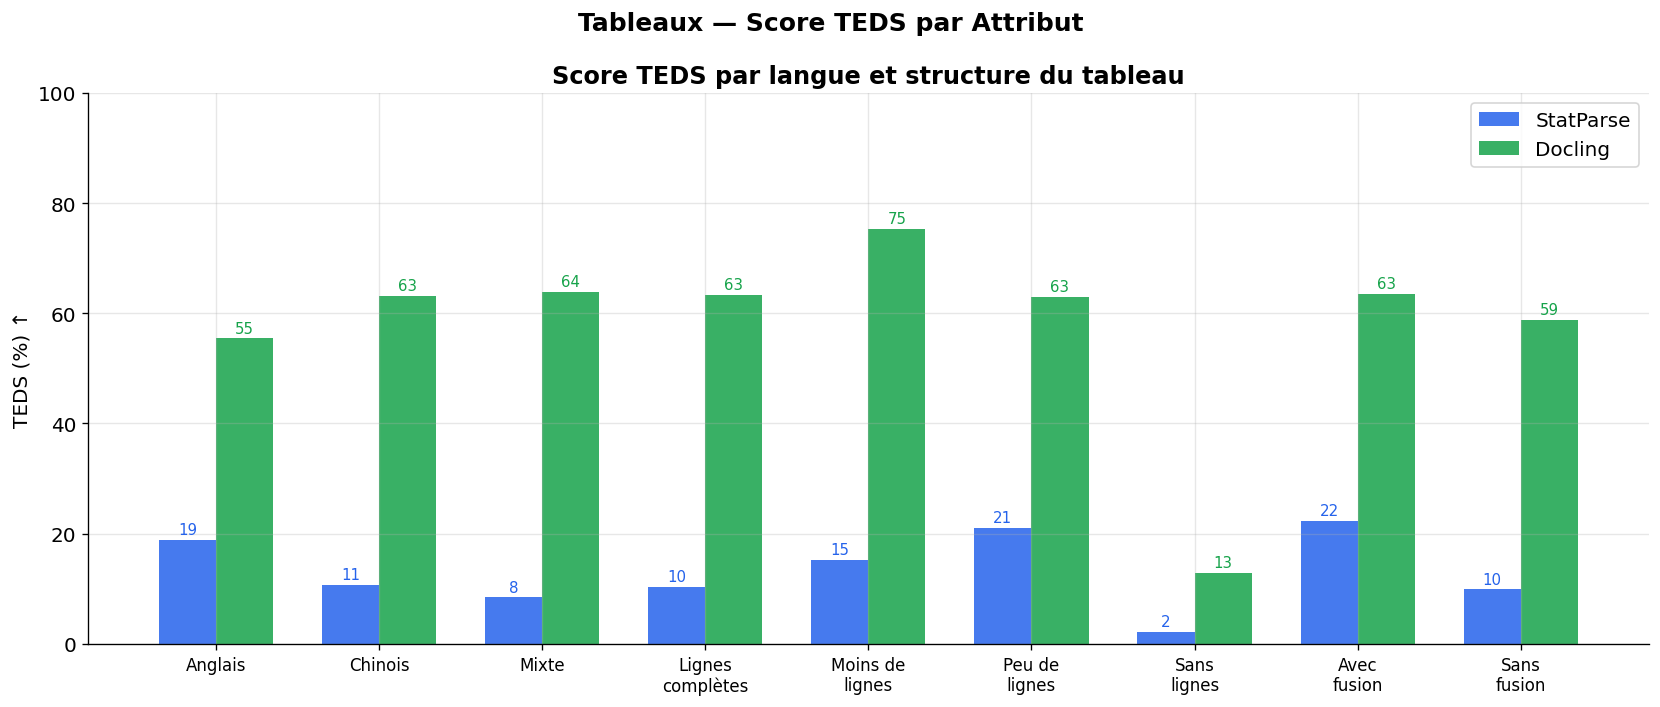

Figure 4 sauvegardée.


In [7]:
# ═══════════════════════════════════════════════════════════════════
# FIGURE 4 — Tableau : TEDS par attribut
# ═══════════════════════════════════════════════════════════════════

table_attrs = {
    'Anglais': 'language: table_en',
    'Chinois': 'language: table_simplified_chinese',
    'Mixte': 'language: table_en_ch_mixed',
    'Lignes\ncomplètes': 'line: full_line',
    'Moins de\nlignes': 'line: less_line',
    'Peu de\nlignes': 'line: fewer_line',
    'Sans\nlignes': 'line: wireless_line',
    'Avec\nfusion': 'with_span: True',
    'Sans\nfusion': 'with_span: False',
}

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Tableaux — Score TEDS par Attribut', fontsize=15, fontweight='bold')

x = np.arange(len(table_attrs))
w = 0.35
labels = list(table_attrs.keys())
keys   = list(table_attrs.values())

sp_teds = [sp['table']['group']['TEDS'].get(k, 0) * 100 for k in keys]
dl_teds = [dl['table']['group']['TEDS'].get(k, 0) * 100 for k in keys]

b1 = ax.bar(x - w/2, sp_teds, w, label='StatParse', color=C_STATPARSE, alpha=0.85)
b2 = ax.bar(x + w/2, dl_teds, w, label='Docling',   color=C_DOCLING,   alpha=0.85)

# Valeurs sur barres
for bar, val in zip(b1, sp_teds):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9, color=C_STATPARSE)
for bar, val in zip(b2, dl_teds):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9, color=C_DOCLING)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('TEDS (%) ↑')
ax.set_ylim(0, 100)
ax.legend(fontsize=12)
ax.set_title('Score TEDS par langue et structure du tableau')

plt.tight_layout()
plt.savefig('fig4_table_teds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 sauvegardée.')

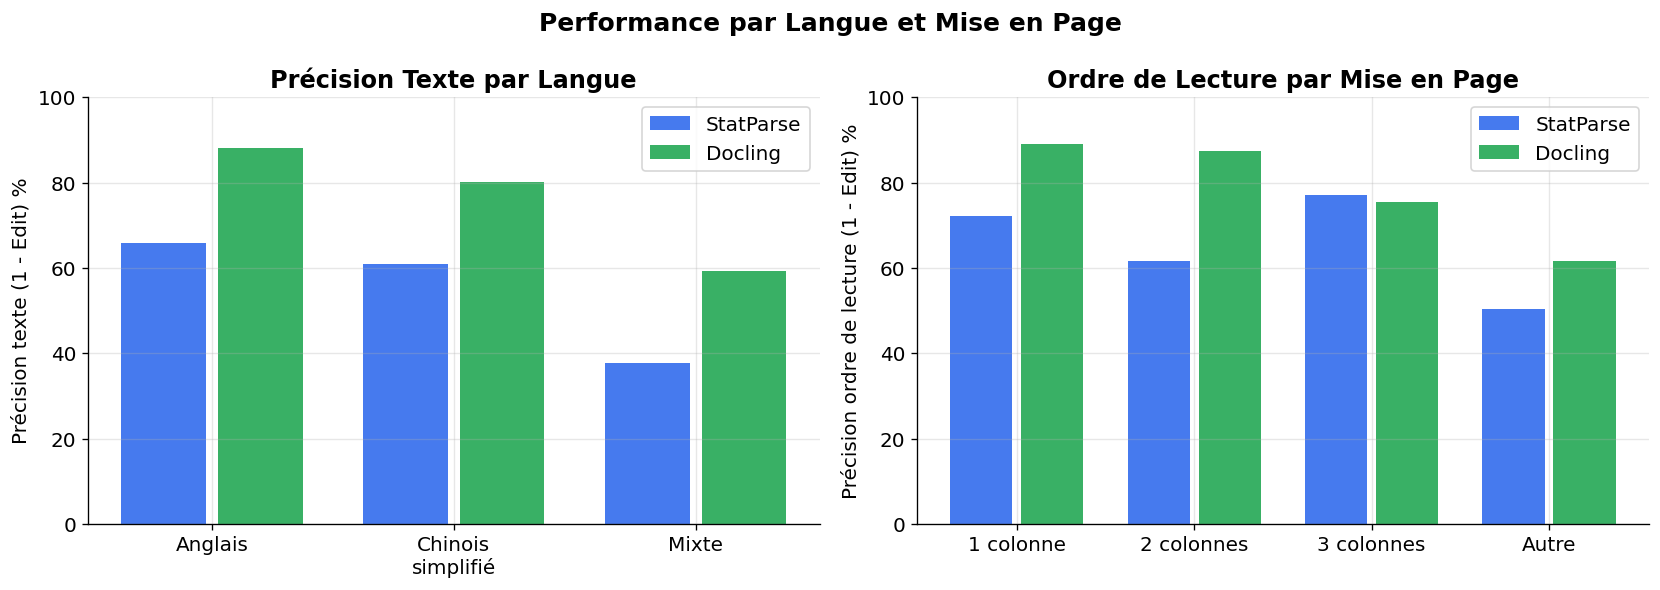

Figure 5 sauvegardée.


In [8]:
# ═══════════════════════════════════════════════════════════════════
# FIGURE 5 — Performance par langue et layout
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Performance par Langue et Mise en Page', fontsize=15, fontweight='bold')

# ── Par langue ────────────────────────────────────────────────────
ax = axes[0]
langs = {
    'Anglais': 'language: english',
    'Chinois\nsimplifié': 'language: simplified_chinese',
    'Mixte': 'language: en_ch_mixed',
}
x = np.arange(len(langs))
sp_lang = [(1 - sp['text_block']['page']['Edit_dist'].get(v, 1)) * 100 for v in langs.values()]
dl_lang = [(1 - dl['text_block']['page']['Edit_dist'].get(v, 1)) * 100 for v in langs.values()]

b1 = ax.bar(x - 0.2, sp_lang, 0.35, color=C_STATPARSE, label='StatParse', alpha=0.85)
b2 = ax.bar(x + 0.2, dl_lang, 0.35, color=C_DOCLING,   label='Docling',   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(list(langs.keys()))
ax.set_ylabel('Précision texte (1 - Edit) %')
ax.set_title('Précision Texte par Langue')
ax.set_ylim(0, 100)
ax.legend()

# ── Par layout ────────────────────────────────────────────────────
ax = axes[1]
layouts = {
    '1 colonne': 'layout: single_column',
    '2 colonnes': 'layout: double_column',
    '3 colonnes': 'layout: three_column',
    'Autre': 'layout: other_layout',
}
x = np.arange(len(layouts))
sp_lay = [(1 - sp['reading_order']['page']['Edit_dist'].get(v, 1)) * 100 for v in layouts.values()]
dl_lay = [(1 - dl['reading_order']['page']['Edit_dist'].get(v, 1)) * 100 for v in layouts.values()]

b1 = ax.bar(x - 0.2, sp_lay, 0.35, color=C_STATPARSE, label='StatParse', alpha=0.85)
b2 = ax.bar(x + 0.2, dl_lay, 0.35, color=C_DOCLING,   label='Docling',   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(list(layouts.keys()))
ax.set_ylabel('Précision ordre de lecture (1 - Edit) %')
ax.set_title('Ordre de Lecture par Mise en Page')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.savefig('fig5_lang_layout.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 sauvegardée.')

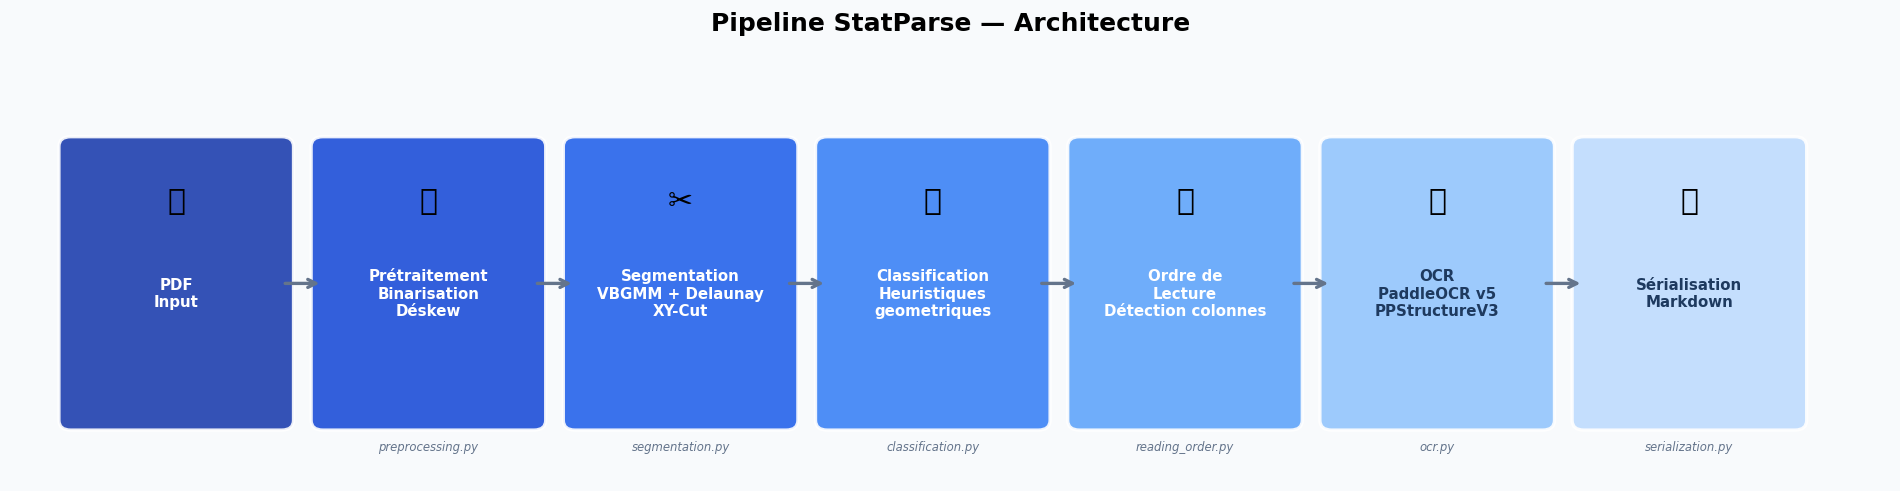

Figure 6 sauvegardée.


In [9]:
# ═══════════════════════════════════════════════════════════════════
# FIGURE 6 — Pipeline StatParse : schéma des étapes
# ═══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 4)
ax.axis('off')
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('#F8FAFC')
fig.suptitle('Pipeline StatParse — Architecture', fontsize=15, fontweight='bold', y=1.02)

steps = [
    ('PDF\nInput', '#1E40AF', '📄'),
    ('Prétraitement\nBinarisation\nDéskew', '#1D4ED8', '🔧'),
    ('Segmentation\nVBGMM + Delaunay\nXY-Cut', '#2563EB', '✂️'),
    ('Classification\nHeuristiques\ngeometriques', '#3B82F6', '🏷️'),
    ('Ordre de\nLecture\nDétection colonnes', '#60A5FA', '📑'),
    ('OCR\nPaddleOCR v5\nPPStructureV3', '#93C5FD', '🔍'),
    ('Sérialisation\nMarkdown', '#BFDBFE', '📝'),
]

box_w = 1.8
box_h = 2.8
start_x = 0.5
gap = 0.35

for i, (name, color, emoji) in enumerate(steps):
    x = start_x + i * (box_w + gap)
    y = 0.6
    
    # Box
    rect = mpatches.FancyBboxPatch(
        (x, y), box_w, box_h,
        boxstyle='round,pad=0.1',
        facecolor=color, edgecolor='white', linewidth=2, alpha=0.9
    )
    ax.add_patch(rect)
    
    # Emoji
    ax.text(x + box_w/2, y + box_h - 0.4, emoji, 
            ha='center', va='top', fontsize=18)
    
    # Texte
    text_color = 'white' if i < 5 else '#1E3A5F'
    ax.text(x + box_w/2, y + box_h/2 - 0.1, name, 
            ha='center', va='center', fontsize=9,
            color=text_color, fontweight='bold',
            multialignment='center')
    
    # Flèche
    if i < len(steps) - 1:
        ax.annotate('', 
            xy=(x + box_w + gap, y + box_h/2),
            xytext=(x + box_w, y + box_h/2),
            arrowprops=dict(arrowstyle='->', color='#64748B', lw=2)
        )

# Auteurs
authors = ['Timothée', 'Omar', 'Omar', 'Omar', 'PaddleOCR', 'Omar\nEdgar']
step_modules = [
    'preprocessing.py', 'segmentation.py', 'classification.py',
    'reading_order.py', 'ocr.py', 'serialization.py'
]
for i, (author, module) in enumerate(zip(authors, step_modules)):
    x = start_x + (i+1) * (box_w + gap)
    ax.text(x + box_w/2, 0.4, module, ha='center', va='top',
            fontsize=7, color='#64748B', style='italic')

plt.tight_layout()
plt.savefig('fig6_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 sauvegardée.')

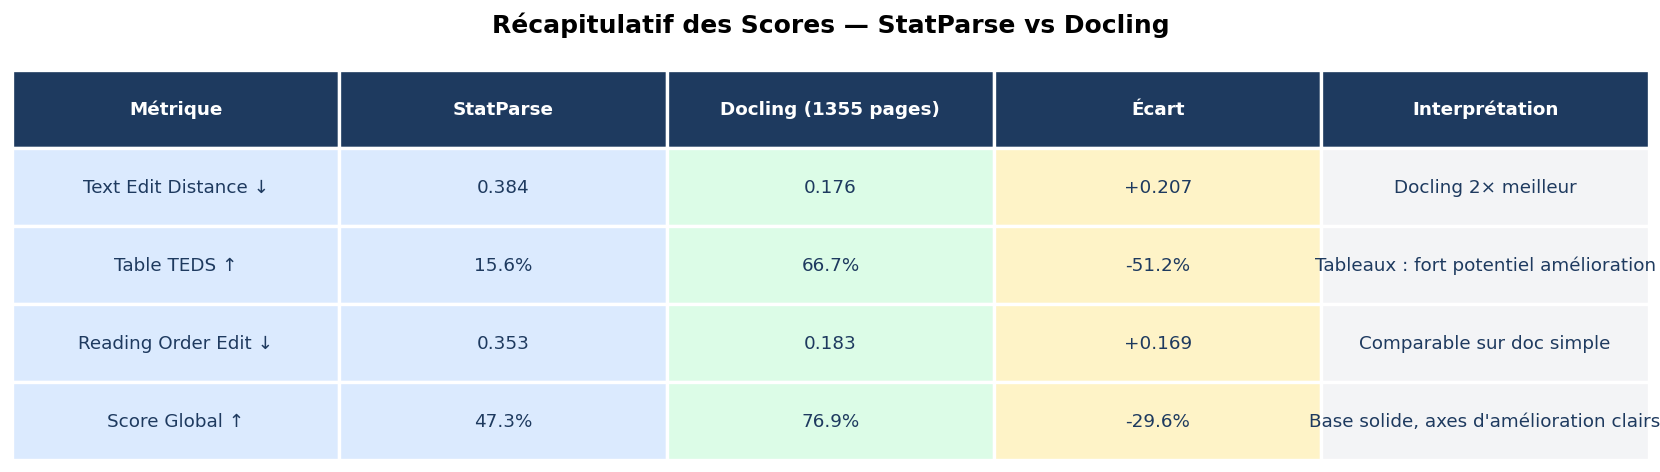

Figure 7 sauvegardée.


In [10]:
# ═══════════════════════════════════════════════════════════════════
# FIGURE 7 — Tableau récapitulatif final stylisé
# ═══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
fig.suptitle('Récapitulatif des Scores — StatParse vs Docling', 
             fontsize=15, fontweight='bold')

table_data = [
    ['Métrique', 'StatParse', 'Docling (1355 pages)', 'Écart', 'Interprétation'],
    ['Text Edit Distance ↓', 
     f"{sp_scores['text_Edit_dist']:.3f}",
     f"{dl_scores['text_Edit_dist']:.3f}",
     f"+{sp_scores['text_Edit_dist'] - dl_scores['text_Edit_dist']:.3f}",
     'Docling 2× meilleur'],
    ['Table TEDS ↑',
     f"{sp_scores['table_TEDS']:.1f}%",
     f"{dl_scores['table_TEDS']:.1f}%",
     f"-{dl_scores['table_TEDS'] - sp_scores['table_TEDS']:.1f}%",
     'Tableaux : fort potentiel amélioration'],
    ['Reading Order Edit ↓',
     f"{sp_scores['reading_order']:.3f}",
     f"{dl_scores['reading_order']:.3f}",
     f"+{sp_scores['reading_order'] - dl_scores['reading_order']:.3f}",
     'Comparable sur doc simple'],
    ['Score Global ↑',
     f"{sp_scores['overall']:.1f}%",
     f"{dl_scores['overall']:.1f}%",
     f"-{dl_scores['overall'] - sp_scores['overall']:.1f}%",
     'Base solide, axes d\'amélioration clairs'],
]

colors_rows = [
    ['#1E3A5F'] * 5,
    [C_LIGHT_SP, C_LIGHT_SP, C_LIGHT_DL, '#FEF3C7', '#F3F4F6'],
    [C_LIGHT_SP, C_LIGHT_SP, C_LIGHT_DL, '#FEF3C7', '#F3F4F6'],
    [C_LIGHT_SP, C_LIGHT_SP, C_LIGHT_DL, '#FEF3C7', '#F3F4F6'],
    [C_LIGHT_SP, C_LIGHT_SP, C_LIGHT_DL, '#FEF3C7', '#F3F4F6'],
]
text_colors = [['white']*5] + [['#1E3A5F']*5] * 4

table = ax.table(
    cellText=table_data,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(11)

for (row, col), cell in table.get_celld().items():
    cell.set_facecolor(colors_rows[row][col])
    cell.set_text_props(color=text_colors[row][col],
                        fontweight='bold' if row == 0 else 'normal')
    cell.set_edgecolor('white')
    cell.set_linewidth(2)

plt.tight_layout()
plt.savefig('fig7_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 sauvegardée.')

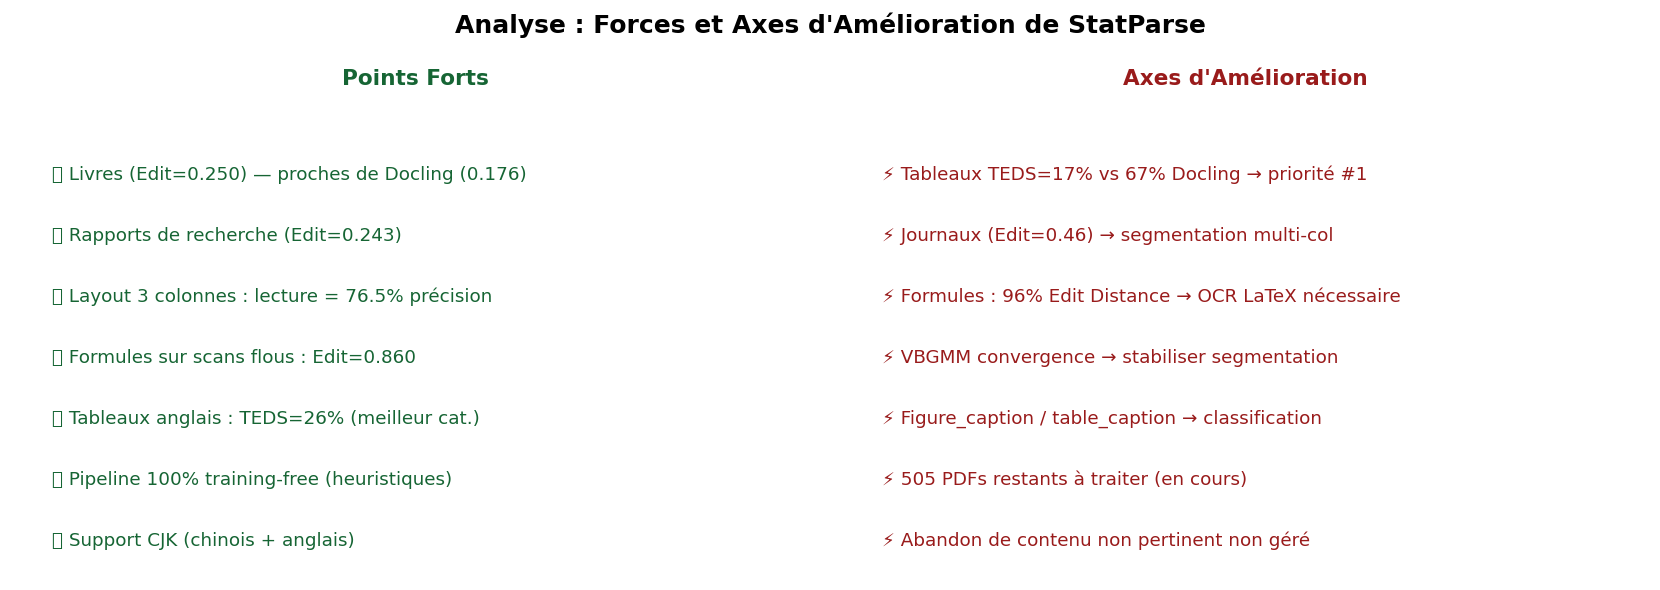

Figure 8 sauvegardée.


In [11]:
# ═══════════════════════════════════════════════════════════════════
# FIGURE 8 — Points forts et axes d'amélioration
# ═══════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analyse : Forces et Axes d\'Amélioration de StatParse', 
             fontsize=15, fontweight='bold')

# ── Points forts : meilleurs cas ─────────────────────────────────
ax1.set_facecolor('#F0FFF4')
ax1.axis('off')
strengths = [
    '✅ Livres (Edit=0.250) — proches de Docling (0.176)',
    '✅ Rapports de recherche (Edit=0.243)',
    '✅ Layout 3 colonnes : lecture = 76.5% précision',
    '✅ Formules sur scans flous : Edit=0.860',
    '✅ Tableaux anglais : TEDS=26% (meilleur cat.)',
    '✅ Pipeline 100% training-free (heuristiques)',
    '✅ Support CJK (chinois + anglais)',
]
ax1.set_title('Points Forts', fontsize=13, fontweight='bold', color='#166534', pad=15)
for i, s in enumerate(strengths):
    ax1.text(0.05, 0.88 - i*0.13, s, transform=ax1.transAxes,
             fontsize=11, va='top', color='#166534')

# ── Axes d'amélioration ───────────────────────────────────────────
ax2.set_facecolor('#FFF5F5')
ax2.axis('off')
improvements = [
    '⚡ Tableaux TEDS=17% vs 67% Docling → priorité #1',
    '⚡ Journaux (Edit=0.46) → segmentation multi-col',
    '⚡ Formules : 96% Edit Distance → OCR LaTeX nécessaire',
    '⚡ VBGMM convergence → stabiliser segmentation',
    '⚡ Figure_caption / table_caption → classification',
    '⚡ 505 PDFs restants à traiter (en cours)',
    '⚡ Abandon de contenu non pertinent non géré',
]
ax2.set_title('Axes d\'Amélioration', fontsize=13, fontweight='bold', color='#991B1B', pad=15)
for i, s in enumerate(improvements):
    ax2.text(0.05, 0.88 - i*0.13, s, transform=ax2.transAxes,
             fontsize=11, va='top', color='#991B1B')

plt.tight_layout()
plt.savefig('fig8_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 sauvegardée.')